In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv(
    r"D:\Retail Pulse Project\data\cleaned_retail.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_29440\3539226486.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [6]:
daily_sales = (
    df.groupby(
        df["InvoiceDate"]
        .dt.date
    )["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = [
    "ds",
    "y"
]

In [14]:
import sys
print(sys.executable)

c:\Users\PAVILION\anaconda3\python.exe


In [15]:
%pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 932.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/12.1 MB 884.1 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/12.1 MB 884.1 kB/s eta 0:00:13
   --- ------------------------------------ 1.0/12.1 MB 932.9 kB/s eta 0:00:12
   ---- ----------------------------------- 1.3/12.1 MB 894.7 kB/s eta 0:00:13
   ----- ---------------------------------- 1.6/12.1 MB 953.2 kB/s eta 0:00:12
   ------ --------------------------------- 1.8/12.1 MB 967.9 kB/s eta 0:00:11
   ------ --------------------------------- 2.1/12.1 MB 1.0 MB/s eta 0:00:10
   ------ --------------------------------- 2.1/12.1 MB 1.0 MB/s eta 0:00:10
   ------- -------------------------------- 2.4/12.1 MB 965.5 kB/s eta 0:00:11
   -

In [16]:
from prophet import Prophet

model = Prophet()

In [17]:
from prophet import Prophet

model = Prophet()

model.fit(
    daily_sales
)

23:28:46 - cmdstanpy - INFO - Chain [1] start processing
23:28:47 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(
    future
)

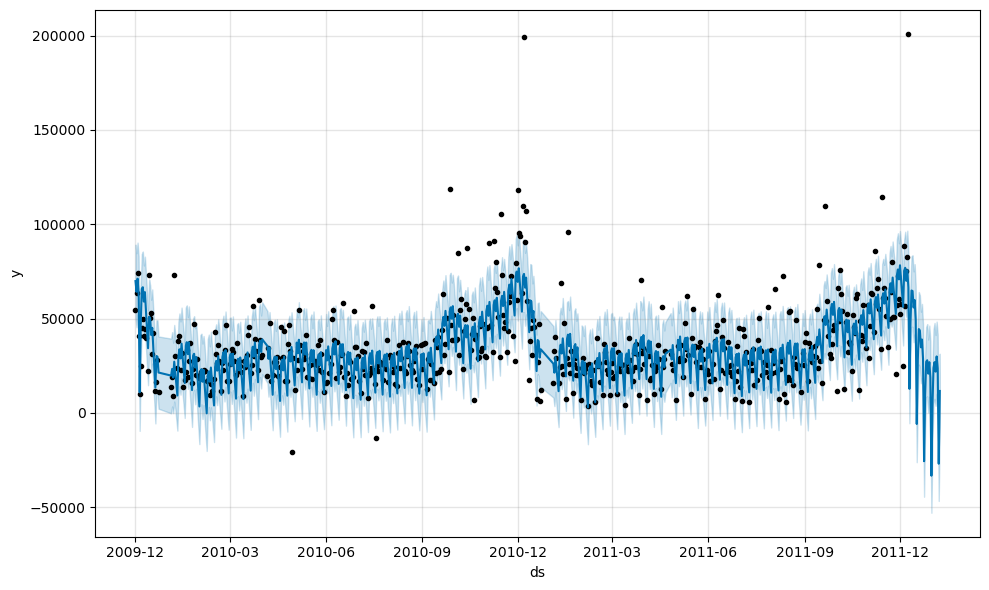

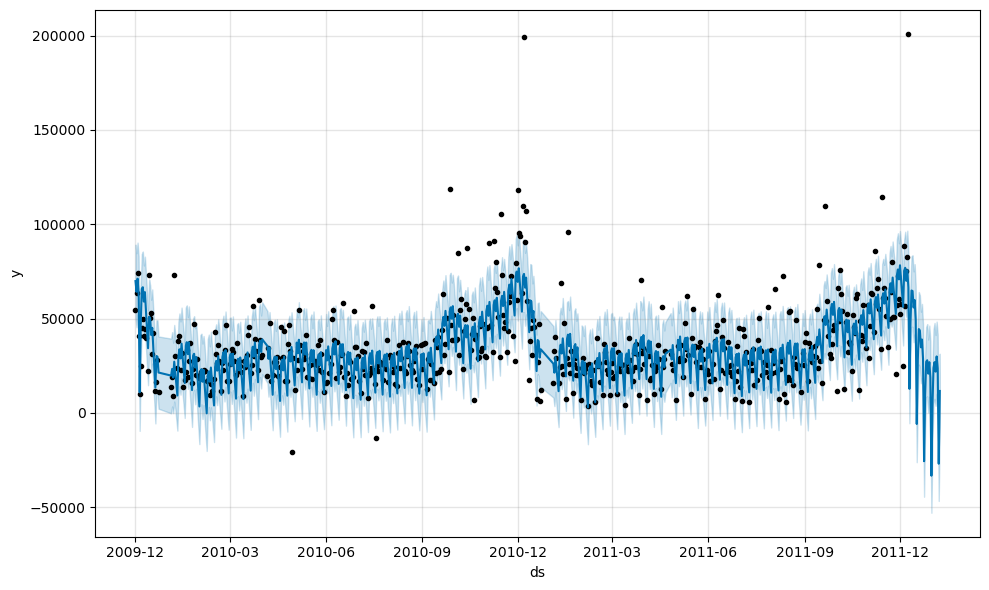

In [20]:
model.plot(forecast)

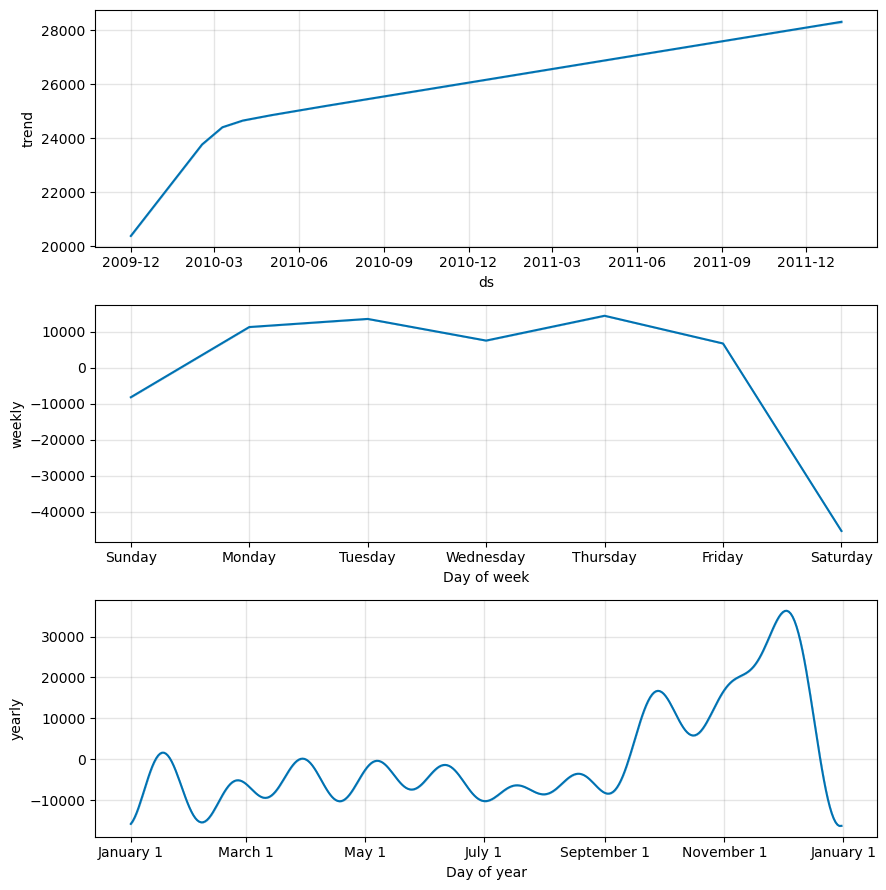

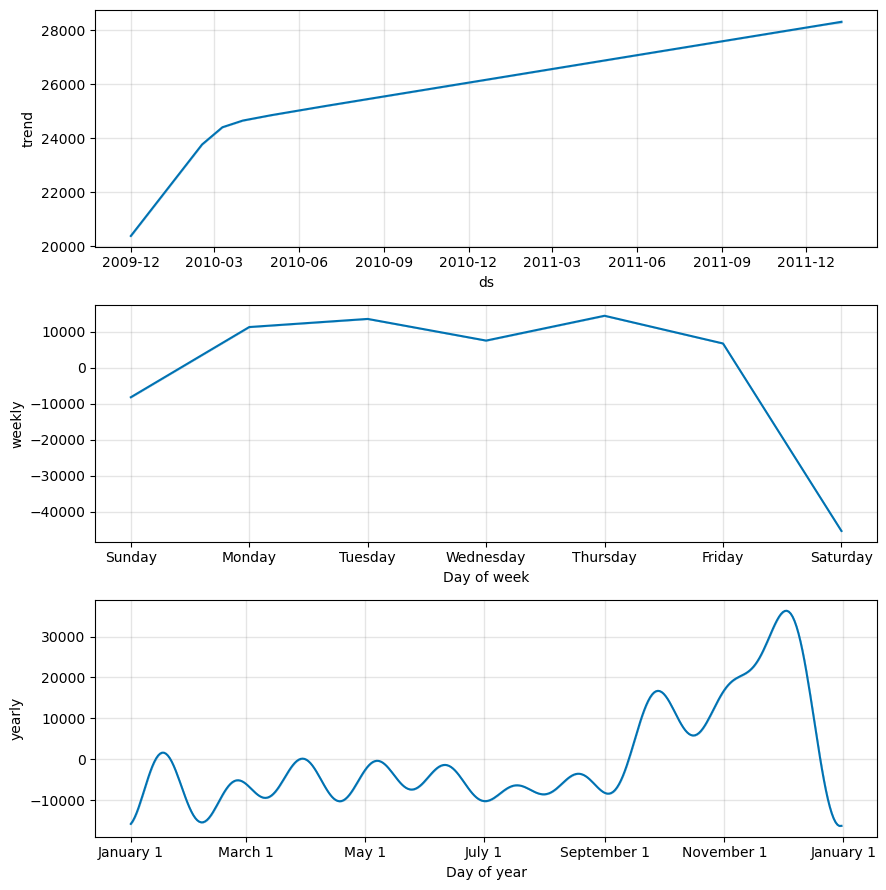

In [21]:
model.plot_components(forecast)

In [19]:
forecast[
    ["ds","yhat"]
].to_csv(
    r"D:\Retail Pulse Project\data\sales_forecast.csv",
    index=False
)
print("Successfully Created!!")

Successfully Created!!
